In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


/tmp/ipython-input-619826994.py:25: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  nandi_union = nandi.geometry.unary_union


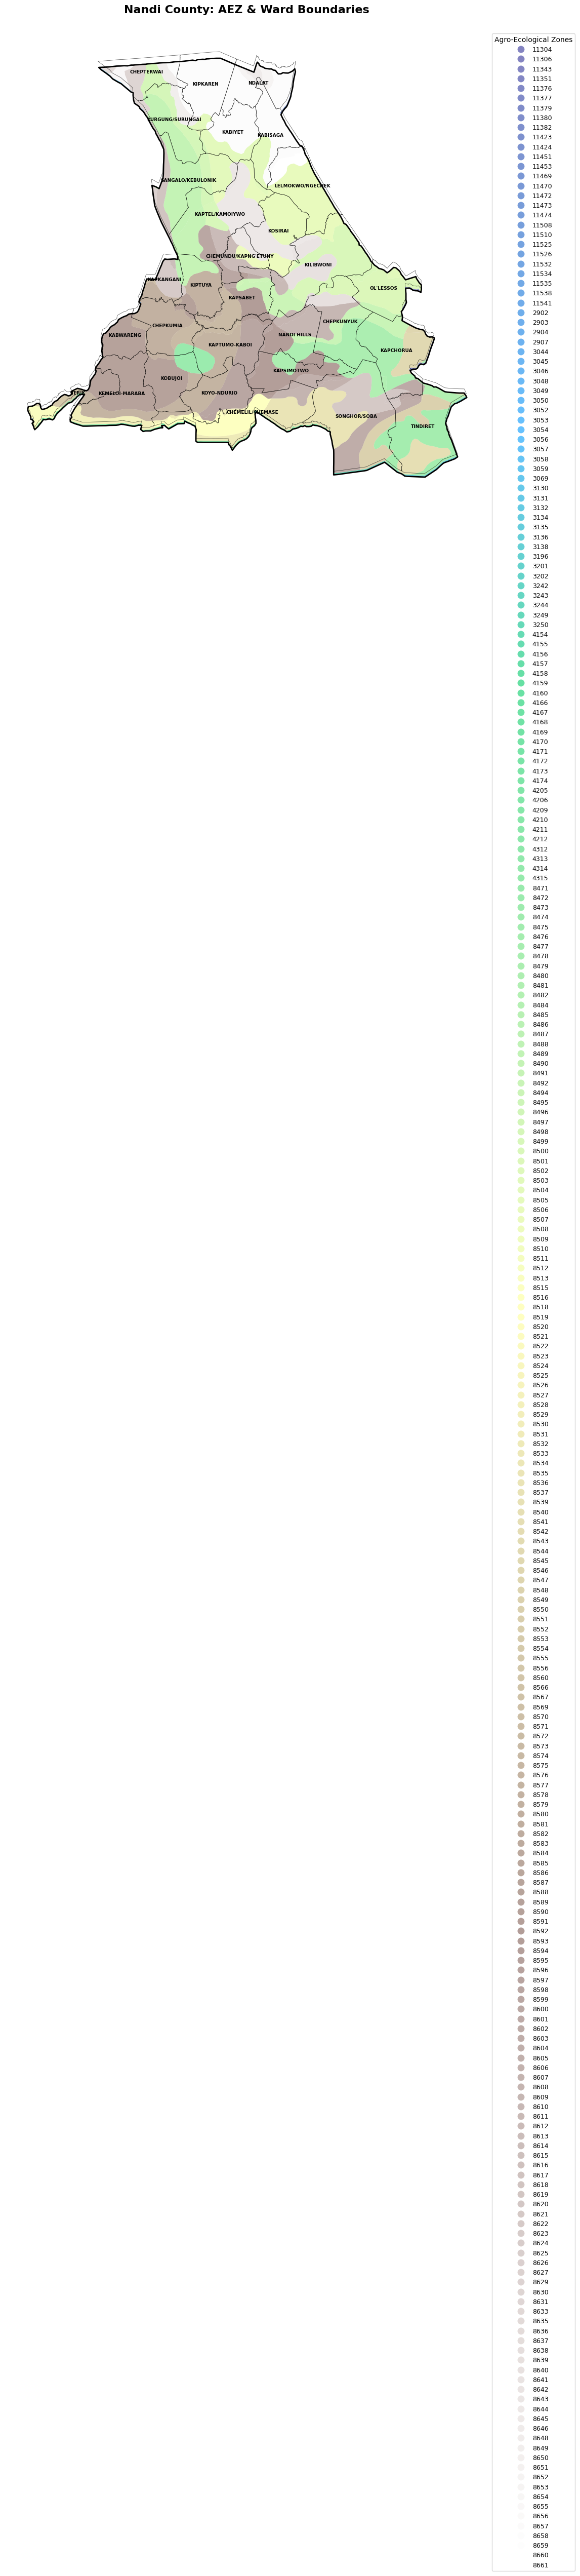

In [14]:
import geopandas as gpd
import matplotlib.pyplot as plt
import os

# Paths
BASE        = '/content/drive/MyDrive/02_NandiSeedRecommender2'
OUT_DIR     = os.path.join(BASE, 'WardAggregatedData')
COUNTY_SHP  = os.path.join(BASE, 'NandiCounties/counties.shp')
AEZ_SHP     = os.path.join(BASE, 'AgroEcological Zones/Kenya_Agro-Ecological_Zones_Data.shp')
WARD_GEO    = os.path.join(OUT_DIR, 'Nandi_Ward_Aggregation.geojson')

# 1. Load Data
aez_all = gpd.read_file(AEZ_SHP)
county  = gpd.read_file(COUNTY_SHP)
wards   = gpd.read_file(WARD_GEO)

# 2. Project to Kenya-specific CRS (EPSG:21037) for accurate centroids/areas
# This resolves the UserWarning
kenya_crs = "EPSG:21037"
nandi = county[county['COUNTY_NAM'] == 'NANDI'].to_crs(kenya_crs)
aez_all = aez_all.to_crs(kenya_crs)
wards = wards.to_crs(kenya_crs)

# 3. Filter Wards & Exclude Manda-Shivanga
nandi_union = nandi.geometry.unary_union
nandi_wards = wards[wards.geometry.centroid.within(nandi_union)].copy()

name_col = next((c for c in nandi_wards.columns if 'NAME' in c.upper() or 'WARD' in c.upper()), None)
if name_col:
    nandi_wards = nandi_wards[~nandi_wards[name_col].str.contains('MANDA', case=False, na=False)]

# 4. Extract and Clip AEZ
aez_all['geometry'] = aez_all.geometry.buffer(0).make_valid()
nandi_aez = gpd.sjoin(aez_all, nandi, how="inner", predicate="intersects")
nandi_aez = gpd.clip(nandi_aez, nandi)

# 5. FIX LEGEND: Force removal of non-Nandi categories
aez_col = next((c for c in ['ZONE', 'AEZ_NAME', 'AEZ', 'ZONES'] if c in nandi_aez.columns), nandi_aez.columns[0])

# Convert to string and back to categorical to reset the "index" of categories
nandi_aez[aez_col] = nandi_aez[aez_col].astype(str)
# This removes all categories that aren't physically present in Nandi
nandi_aez = nandi_aez[nandi_aez[aez_col] != 'nan']

# 6. Plotting
fig, ax = plt.subplots(figsize=(14, 12))

# Plot AEZ (Categorical=True is key)
nandi_aez.plot(
    ax=ax,
    column=aez_col,
    cmap='terrain',
    legend=True,
    categorical=True,
    alpha=0.6,
    edgecolor='none',
    legend_kwds={
        'title': "Agro-Ecological Zones",
        'loc': 'upper left',
        'bbox_to_anchor': (1, 1),
        'fontsize': 9
    }
)

# Plot Ward Boundaries
nandi_wards.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.5, alpha=0.7)

# Plot County Boundary
nandi.boundary.plot(ax=ax, color='black', linewidth=2)

# Add Ward Labels using the now-accurate projected centroids
for x, y, label in zip(nandi_wards.geometry.centroid.x,
                        nandi_wards.geometry.centroid.y, nandi_wards[name_col]):
    ax.text(x, y, label, fontsize=6.5, ha='center', weight='bold')

plt.title('Nandi County: AEZ & Ward Boundaries', fontsize=16, fontweight='bold', pad=25)
plt.axis('off')

# Save and Show
plt.savefig(os.path.join(OUT_DIR, 'Nandi_AEZ_Ward_Overlay.png'), dpi=300, bbox_inches='tight')
plt.show()

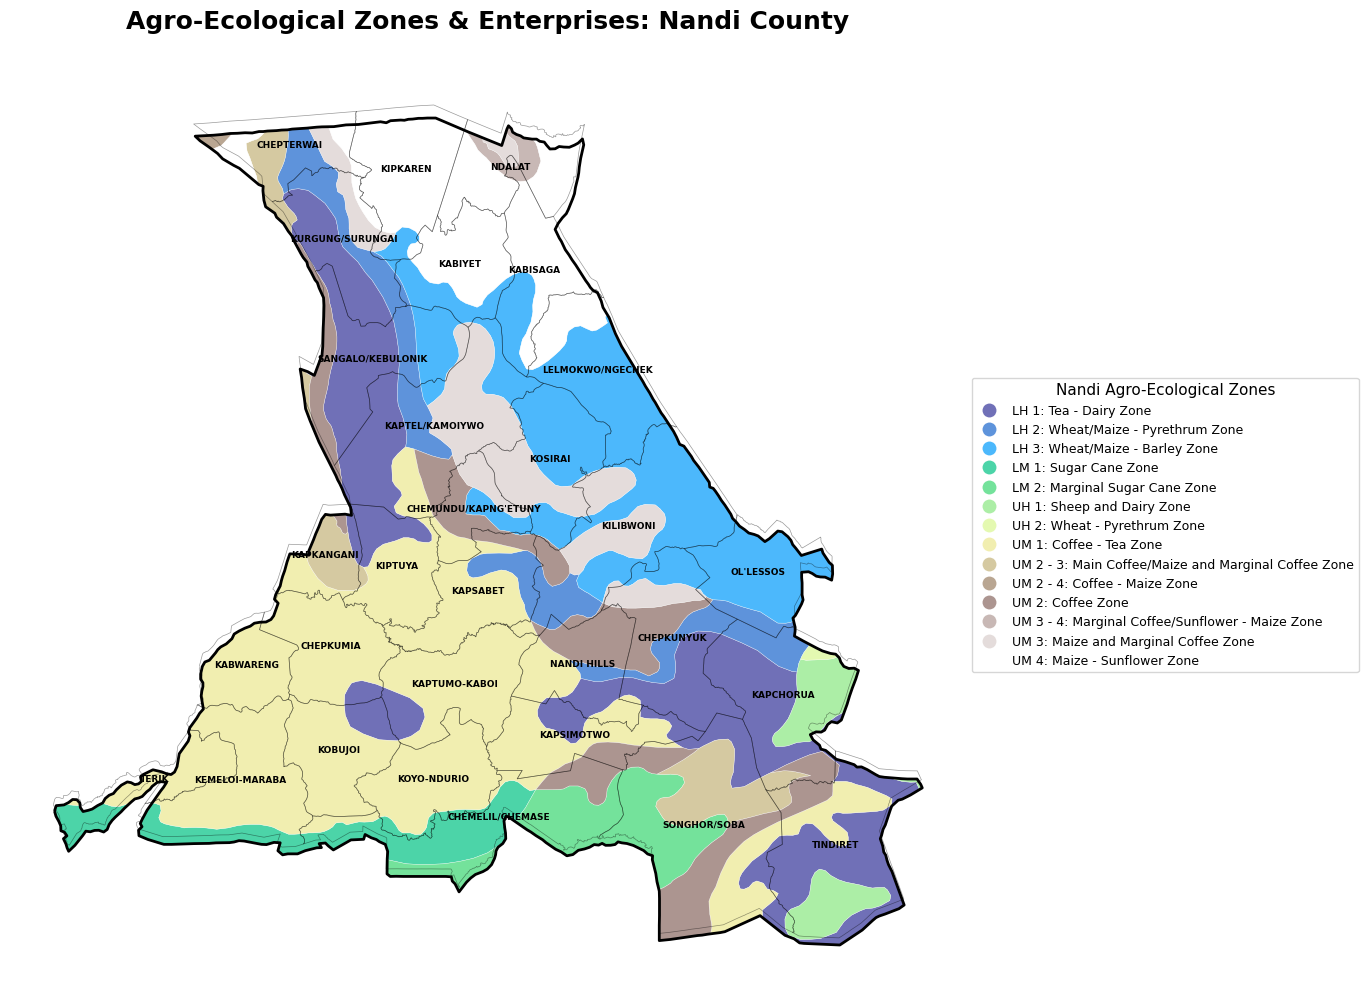

In [19]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import os

# 1. Setup Data (Assuming variables from previous blocks)
kenya_crs = "EPSG:21037"

# 2. CREATE A DESCRIPTIVE COLUMN
# We will combine the Code and the Enterprise for maximum clarity
nandi_aez['Zone_Description'] = (
    nandi_aez['AEZ_Code'].astype(str) + ": " + nandi_aez['Enterprise'].astype(str)
)

# 3. CLEAN UP STRINGS
nandi_aez['Zone_Description'] = nandi_aez['Zone_Description'].str.replace('nan', '').str.strip(': ')
nandi_aez = nandi_aez[nandi_aez['Zone_Description'] != ''].copy()

# 4. RESET CATEGORIES (The "Memory" Fix)
# This ensures the legend ONLY shows what is physically in Nandi
nandi_aez['Zone_Description'] = pd.Categorical(nandi_aez['Zone_Description'])
nandi_aez['Zone_Description'] = nandi_aez['Zone_Description'].cat.remove_unused_categories()

# 5. DISSOLVE
# Merges all small slivers of the same zone together
nandi_aez = nandi_aez.dissolve(by='Zone_Description').reset_index()

# 6. PLOTTING
fig, ax = plt.subplots(figsize=(16, 12))

nandi_aez.plot(
    ax=ax,
    column='Zone_Description',
    cmap='terrain',
    legend=True,
    categorical=True,
    alpha=0.7,
    edgecolor='white',
    linewidth=0.3,
    legend_kwds={
        'title': "Nandi Agro-Ecological Zones",
        'loc': 'center left',
        'bbox_to_anchor': (1, 0.5),
        'fontsize': 9,
        'title_fontsize': 11
    }
)

# Overlay Ward Boundaries
nandi_wards.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.5, alpha=0.4)

# Thick County Border
nandi.boundary.plot(ax=ax, color='black', linewidth=2)

# Ward Labels
for x, y, label in zip(nandi_wards.geometry.centroid.x,
                        nandi_wards.geometry.centroid.y, nandi_wards[name_col]):
    ax.text(x, y, label, fontsize=6.5, ha='center', weight='bold', color='black')

plt.title('Agro-Ecological Zones & Enterprises: Nandi County', fontsize=18, fontweight='bold', pad=25)
ax.set_axis_off()

plt.savefig(os.path.join(OUT_DIR, 'Nandi_AEZ_Named_Map.png'), dpi=300, bbox_inches='tight')
plt.show()

In [18]:
# List all column names to find the descriptive ones
print(nandi_aez.columns.tolist())

# View the first few rows to identify which column has names like 'UM 1' or 'Upper Midlands'
print(nandi_aez.head())

['FID', 'geometry', 'County', 'Sub_County', 'AEZ_Code', 'AEZ_Name', 'AEZSubzone', 'AREA', 'Enterprise', 'Shape__Are', 'Shape__Len', 'index_right', 'OBJECTID', 'ID_', 'COUNTY_NAM', 'CONST_CODE', 'CONSTITUEN', 'COUNTY_COD', 'Shape_Leng', 'Shape_Area']
     FID                                           geometry       County  \
0  11304  POLYGON ((94379.798 10007513.013, 94379.96 100...  Uasin Gishu   
1  11306  POLYGON ((91884.193 10016067.208, 91879.073 10...  Uasin Gishu   
2  11343  MULTIPOLYGON (((92553.893 10018780.105, 92364....  Uasin Gishu   
3  11351  MULTIPOLYGON (((92240.723 10018178.516, 92098....  Uasin Gishu   
4  11376  POLYGON ((94181.505 10007266.371, 93845.445 10...  Uasin Gishu   

              Sub_County AEZ_Code        AEZ_Name   AEZSubzone          AREA  \
0  Nandi East Sub County     LH 1  Lower Highland  vl i or two   3289.201430   
1  Nandi East Sub County     LH 2  Lower Highland  vl/l or two     11.774235   
2  Nandi East Sub County     LH 3  Lower Highland  l/

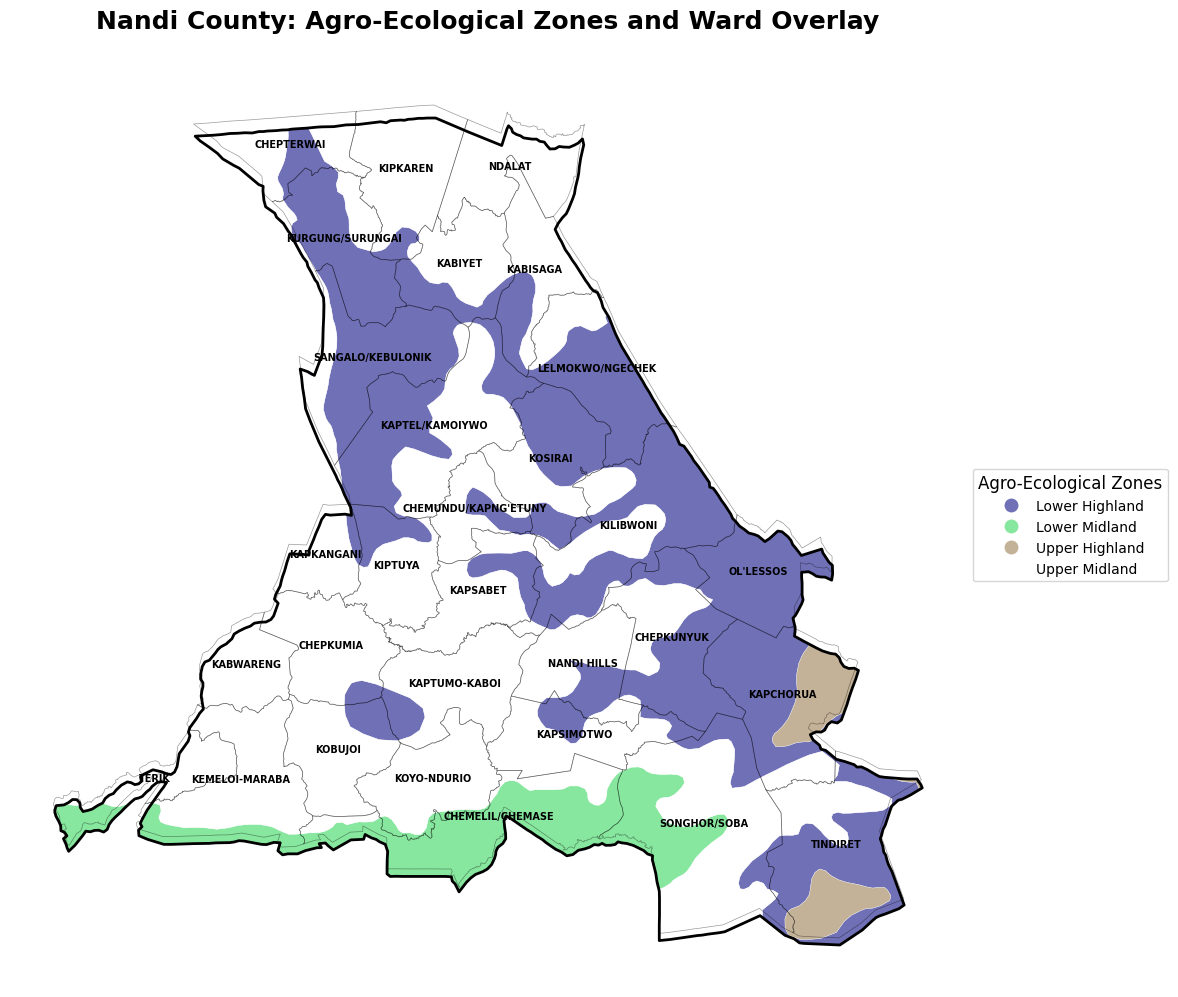

In [20]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import os

# 1. Setup Data
kenya_crs = "EPSG:21037"

# 2. DATA CLEANUP: Focus strictly on AEZ_Name
# Ensure it is a string and remove any whitespace or nulls
nandi_aez['AEZ_Name'] = nandi_aez['AEZ_Name'].astype(str).str.strip()
nandi_aez = nandi_aez[~nandi_aez['AEZ_Name'].isin(['None', 'nan', 'nan ', 'None '])].copy()

# 3. RESET CATEGORIES (The "Memory" Fix)
# This forces the legend to forget the hundreds of other zones in Kenya
nandi_aez['AEZ_Name'] = pd.Categorical(nandi_aez['AEZ_Name'])
nandi_aez['AEZ_Name'] = nandi_aez['AEZ_Name'].cat.remove_unused_categories()

# 4. DISSOLVE
# Merges all polygons with the same name into a single category for the legend
nandi_aez = nandi_aez.dissolve(by='AEZ_Name').reset_index()

# 5. PLOTTING
fig, ax = plt.subplots(figsize=(16, 12))

# Plot AEZ Zones
nandi_aez.plot(
    ax=ax,
    column='AEZ_Name',
    cmap='terrain',
    legend=True,
    categorical=True,
    alpha=0.7,
    edgecolor='white',
    linewidth=0.3,
    legend_kwds={
        'title': "Agro-Ecological Zones",
        'loc': 'center left',
        'bbox_to_anchor': (1, 0.5),
        'fontsize': 10,
        'title_fontsize': 12
    }
)

# Overlay Ward Boundaries (Thin lines)
nandi_wards.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.5, alpha=0.4)

# Thick County Boundary
nandi.boundary.plot(ax=ax, color='black', linewidth=2)

# Ward Labels
for x, y, label in zip(nandi_wards.geometry.centroid.x,
                        nandi_wards.geometry.centroid.y, nandi_wards[name_col]):
    ax.text(x, y, label, fontsize=7, ha='center', weight='bold', color='black')

plt.title('Nandi County: Agro-Ecological Zones and Ward Overlay', fontsize=18, fontweight='bold', pad=25)
ax.set_axis_off()

# Save the final result
output_map = os.path.join(OUT_DIR, 'Nandi_AEZ_Ward_Final.png')
plt.savefig(output_map, dpi=300, bbox_inches='tight')
plt.show()